In [1]:
# Add the parent directory of the current working directory to the Python path at runtime. 
# In order to import modules from the src directory.
import os
import sys 

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

### General setup

In [2]:
import tomllib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from numpy.random import default_rng

from statsmodels.stats.multitest import multipletests
from scipy.stats import norm, multivariate_normal
from scipy.special import expit

from src.anl_utils import load_data
from src.plot_utils import convert_size

with open("../config/simulation/simulation.toml", "rb") as f:
    config = tomllib.load(f)
    rng = default_rng(config["random_seed"])

In [3]:
### Setup for plotting
figsize = [89, 89]
figsize = convert_size(*figsize)

figure_path = '../results/figures/suppl_one/'
os.makedirs(figure_path, exist_ok=True)

### Specific setup for power sensitivity analysis

In [4]:
family = sm.families.Binomial()
covariance_structure = sm.cov_struct.Exchangeable()
gee_specification = (covariance_structure, family)

num_repetitions = 500
factors = np.linspace(0.1,2.,15)
damping_factor = 0.75   # assume effect sizes of non-explored coefficients are only 75% of what was observed in the data (account for potential effect size inflation)
all_coefficients = ['Intercept', 'GridCoarseness', 'ContrastHeterogeneity', 'SessionID', 'ContrastHeterogeneityByGridCoarseness', 'GridCoarsenessBySession', 'ContrastHeterogeneityBySession']

### Utility functions 

In [5]:
def prepare_dataframe(file):
    """
    Prepare the DataFrame for analysis by loading the data, filtering, and scaling.
    
    Parameters
    ----------
    file : str
        The path to the data file.

    Returns
    -------
    pd.DataFrame
        The prepared DataFrame.
    """
    df = load_data(file)
    df = df[df['SessionID'] != 9]
    df = df.drop(columns=['IndicatedOrientation', 'ActualOrientation'])

    df['ContrastHeterogeneityBySession'] = df['ContrastHeterogeneity'] * df['SessionID']
    df['GridCoarsenessBySession'] = df['GridCoarseness'] * df['SessionID']

    df['ContrastHeterogeneityByGridCoarseness'] = df['ContrastHeterogeneity'] * df['GridCoarseness']

    return df

def real_results(df, gee_specification):
    """
    Fit a GEE model and return the coefficients.

    Parameters
    ----------
    df : pd.DataFrame
        The input data for the GEE model.
    gee_specification : tuple
        A tuple containing the covariance structure and family for the GEE model.

    Returns
    -------
    pd.Series
        The coefficients of the fitted GEE model.
    float
        The estimated correlation parameter of the fitted GEE model.
    """
    
    covariance_structure, family = gee_specification
    
    model = smf.gee(
                "Correct ~ GridCoarseness + ContrastHeterogeneity + SessionID + GridCoarsenessBySession + ContrastHeterogeneityBySession + ContrastHeterogeneityByGridCoarseness",
                "SubjectID",
                df,
                cov_struct=covariance_structure,
                family=family)

    results = model.fit()

    return results.params, results.cov_struct.dep_params

def create_design_matrix(df):
    """
    Create the design matrix for the GEE model.

    Parameters
    ----------
    df : pd.DataFrame
        The input data for the design matrix.

    Returns
    -------
    pd.DataFrame
        The design matrix for the GEE model.
    """
    X = sm.add_constant(df[['SessionID', 'GridCoarseness', 'ContrastHeterogeneity', 'GridCoarsenessBySession', 'ContrastHeterogeneityBySession', 'ContrastHeterogeneityByGridCoarseness']].copy())
    X = X.rename(columns={'const': 'Intercept'})

    return X

def create_gee_arrays(df):
    """
    Create the design matrix and groups for the GEE model.

    Parameters
    ----------
    df : pd.DataFrame
        The input data for the GEE model.

    Returns
    -------
    tuple
        A tuple containing the design matrix and groups for the GEE model.
    """
    exog = create_design_matrix(df).to_numpy()
    groups = pd.factorize(df['SubjectID'])[0]
    return exog, groups

def create_effect_sizes(coefficients, fixed_coefficients, explored_coefficients, damping_factor, factor):
    """
    Create effect sizes for fixed and explored coefficients.
    """
    effect_sizes = {}
    for coef in fixed_coefficients:
        effect_sizes[coef] = coefficients[coef] * damping_factor
    for coef in explored_coefficients:
        effect_sizes[coef] = coefficients[coef] * factor
    return effect_sizes

def compute_probabilities(design_matrix, effect_sizes):
    """
    Compute the probabilities for the GEE model.

    Parameters
    ----------
    design_matrix : pd.DataFrame
        The design matrix for the GEE model.
    effect_sizes : dict
        The effect sizes for the GEE model.

    Returns
    -------
    np.ndarray
        The computed probabilities.
    """
    betas = pd.Series(effect_sizes, index=design_matrix.columns).values

    linear_predictor = design_matrix.dot(betas)
    return expit(linear_predictor)

def construct_sample(df, probabilities, alpha):
    """
    Construct a sample dataset based on the provided parameters.

    Parameters
    ----------
    df : pd.DataFrame
        The input data for the sample.
    design_matrix : pd.DataFrame
        The design matrix for the GEE model.
    betas : np.ndarray
        The coefficients for the GEE model.
    alpha : float
        The correlation parameter for the exchangeable correlation structure.

    Returns
    -------
    np.ndarray
        The constructed sample.
    """
    subject_ids, subject_indices = np.unique(df['SubjectID'].to_numpy(), return_index=True)
    subject_ids = subject_ids[np.argsort(subject_indices)] # preserve original order
    num_subjects = len(subject_ids)
    num_trials = (df['SubjectID'] == subject_ids[0]).sum()


    root_alpha = np.sqrt(alpha)
    root_one_minus = np.sqrt(1.0 - alpha)

    z0 = rng.standard_normal(num_subjects)[:, None]
    ziid = rng.standard_normal((num_subjects, num_trials))
    z = root_alpha * z0 + root_one_minus * ziid
    u = norm.cdf(z).ravel(order='C')


    return (u < probabilities).astype(np.int8)

def run_gee(y, exog, groups, gee_specification, indices):
    """
    Run a Generalized Estimating Equations (GEE) model on the provided data.

    Parameters
    ----------
    y : np.ndarray
        The response variable for the GEE model.
    exog : np.ndarray
        The design matrix for the GEE model.
    groups : np.ndarray
        The grouping variable for the GEE model.
    gee_specification : tuple
        A tuple containing the covariance structure and family for the GEE model.
    indices : list
        The indices of the coefficients to extract from the results.

    Returns
    -------
    np.ndarray
        The p-values for the coefficients of the GEE model (limited to the specified indices).
    """
    covariance_structure, family = gee_specification

    model = sm.GEE(endog=y, exog=exog, groups=groups,
                   cov_struct=covariance_structure, family=family)
    result = model.fit()
    return result.pvalues.iloc[indices].to_numpy()

def power_analysis(df, gee_specification, explored_coefficients, fixed_coefficients, factors, repetitions=1000, damping_factor=0.75, alpha=0.05, method='holm'):
    """
    Perform a power analysis for the GEE model.

    Parameters
    ----------
    df : pd.DataFrame
        The input data for the analysis.
    sample_parameters : tuple
        A tuple containing the effect sizes and the variance of the random effects.
    gee_specification : tuple
        A tuple containing the covariance structure and family for the GEE model.
    num_samples : int, optional
        The number of samples to generate (default is 1000).
    alpha : float, optional
        The significance level (default is 0.05).
    method : str, optional
        The multiple testing correction method (default is 'holm').

    Returns
    -------
    float
        The estimated power of the test.
    """

    num_factors = len(factors)
    num_explored = len(explored_coefficients)
    

    power = np.zeros((num_factors, num_explored))

    design_matrix = create_design_matrix(df)
    coefficient_indices = [i for i, coef in enumerate(design_matrix.columns) if coef in explored_coefficients]

    observed_betas, observed_alpha = real_results(df, gee_specification)

    exog, groups = create_gee_arrays(df)

    for i, factor in enumerate(factors):

        effect_sizes = create_effect_sizes(observed_betas, fixed_coefficients, explored_coefficients, damping_factor, factor)
        probabilities = compute_probabilities(design_matrix, effect_sizes)

        for _ in range(repetitions):
            y = construct_sample(df, probabilities, observed_alpha)

            pvals = run_gee(y, exog, groups, gee_specification, coefficient_indices)
            
            reject, _, _, _ = multipletests(pvals, alpha=alpha, method=method)
            
            power[i] += reject

    power /= repetitions

    return power * 100

### Prepare data

In [6]:
data_path = '../data/Experiment.csv'
data = prepare_dataframe(data_path)

### Run analysis and plot results

**Grid Coarseness**

In [7]:
explored_coefficients = ['GridCoarseness']
fixed_coefficients = [coeff for coeff in all_coefficients if coeff not in explored_coefficients]

power_gc = power_analysis(data, gee_specification, explored_coefficients, fixed_coefficients, factors, repetitions = num_repetitions)

/home/mario/miniconda3/envs/bat_env/lib/python3.12/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",
/home/mario/miniconda3/envs/bat_env/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


**Contrast Heterogeneity**

In [8]:
explored_coefficients = ['ContrastHeterogeneity']
fixed_coefficients = [coeff for coeff in all_coefficients if coeff not in explored_coefficients]

power_ch = power_analysis(data, gee_specification, explored_coefficients, fixed_coefficients, factors, repetitions = num_repetitions)

**Grid Coarseness X Session Interaction**

In [9]:
explored_coefficients = ['GridCoarsenessBySession']
fixed_coefficients = [coeff for coeff in all_coefficients if coeff not in explored_coefficients]

power_gcsess = power_analysis(data, gee_specification, explored_coefficients, fixed_coefficients, factors, repetitions = num_repetitions)

**Contrast Heterogeneity X Session Interaction**

In [10]:
explored_coefficients = ['ContrastHeterogeneityBySession']
fixed_coefficients = [coeff for coeff in all_coefficients if coeff not in explored_coefficients]

power_chsess = power_analysis(data, gee_specification, explored_coefficients, fixed_coefficients, factors, repetitions = num_repetitions)

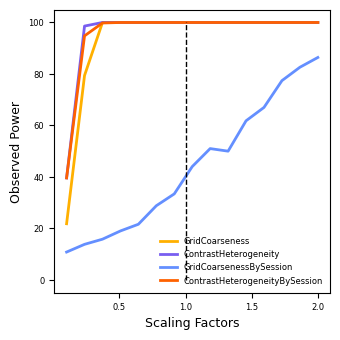

In [11]:
plt.figure(figsize=figsize)
plt.plot(factors, power_gc, color='#ffb000', linewidth=2, label='GridCoarseness')
plt.plot(factors, power_ch, color='#785ef0', linewidth=2, label='ContrastHeterogeneity')
plt.plot(factors, power_gcsess, color='#648fff', linewidth=2, label='GridCoarsenessBySession')
plt.plot(factors, power_chsess, color='#fe6100', linewidth=2, label='ContrastHeterogeneityBySession')
plt.vlines(x=1, ymin=0, ymax=100, color="#000000", linestyle='--', linewidth=1)
plt.xlabel('Scaling Factors', fontsize=9)
plt.ylabel('Observed Power', fontsize=9)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.legend(fontsize=6, frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'power_analysis.svg'), format='svg')